In [28]:
import cv2
# from matplotlib import pyplot as plt
import numpy as np
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator

import os
now_path = os.getcwd()
image_path = os.path.join(now_path, 'picture/People.jpg')
model_path = os.path.join(now_path, 'model/yolov8m.pt')
confidence_threshold = 0.5
man = 2 #保存第几个人

In [34]:
def main():
    model = YOLO(model_path)  # 加载预训练的YOLOv8模型
    img = cv2.imread(image_path)
    #进行检测
    results = model(image_path, conf = 0.25) 
    #返回一个列表,这个列表里面存储着每个检测结果的对象
    #每个对象包含了检测到的边界框、类别、置信度等信息。

    # 处理每个结果
    """
    results是列表
    results[n]结果对象——存储一整张图片的信息！
    结果对象
    """
    r = results[0]
    annotator = Annotator(r.orig_img.copy(), line_width=2,example=str)
    """
    之后r本身有很多属性，这里用到了orig_img属性，表示原始图像。
    boxes属性，边界框信息，分别存储在boxes的属性里面
    然后box属性本身也是套属性（类别、置信度、坐标）因此才有r本身的绘制出图
    
    """
    # 计数准备
    person_count = 0
    all_crops = []
    #===============================检测结果处理===============================
    for box in r.boxes:
        cls_id = int(box.cls[0].item())#类别id可能是数组
        cls_name = model.names[cls_id]  # 获取类别名称
        label = f"{cls_name} {box.conf[0]:.2f}" 

        # 获取边界框坐标和类别
        xyxy = box.xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        conf = float(box.conf[0].item())  # 获取置信度
           # 大小：(高, 宽, 3)
        h = y2 - y1
        w = x2 - x1

        
        # 按老师示例风格打印



        # 计数画框
        if conf >= confidence_threshold:
            person_count += 1
            label = f"{person_count} {conf:.2f}"
            print(
            f"person{person_count}: 置信度{conf:.2f}，大小：({h},{w},3) | "
            f"位置：左上点（{x1},{y1}），右下点（{x2},{y2}）"
            )

            crop = img[y1:y2, x1:x2]
            all_crops.append(crop)
            annotator.box_label([x1,y1,x2,y2], label=label, color=(255, 0, 0))  # 绘制边界框和标签

    print(f"检测到 {person_count} 个人")    
#==============================图片展示===============================
    """不用box.mask,因为这个是像素级别的"""
    # 单个人的展示
    # 裁剪出单个人
    crop = img[y1:y2, x1:x2]
    
    

    

    # 保存带框图片
    annotator_img = annotator.result()
    cv2.imwrite('people_result.jpg', annotator_img)
    print("检测结果已保存为 people_result.jpg") 


    # 展示第man个人
    cv2.imshow(f'person{person_count}', all_crops[man])
    cv2.waitKey(0)
    cv2.destroyAllWindows()


    # 展示带框图片
    h, w = annotator_img.shape[:2]
    max_w, max_h = 1000, 700
    scale = min(max_w / w, max_h / h, 1.0)
    show_img = cv2.resize(annotator_img, (int(w * scale), int(h * scale)))
    cv2.imshow('YOLOv8 Detection', show_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()




if __name__ == "__main__":
    main()





image 1/1 c:\Users\Lenovo\Desktop\PBLF\\picture\People.jpg: 640x544 4 persons, 15.7ms
Speed: 5.1ms preprocess, 15.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 544)
person1: 置信度0.94，大小：(361,108,3) | 位置：左上点（223,92），右下点（331,453）
person2: 置信度0.94，大小：(325,124,3) | 位置：左上点（20,128），右下点（144,453）
person3: 置信度0.94，大小：(340,116,3) | 位置：左上点（125,112），右下点（241,452）
person4: 置信度0.80，大小：(75,32,3) | 位置：左上点（337,165），右下点（369,240）
检测到 4 个人
检测结果已保存为 people_result.jpg


# 运行结果
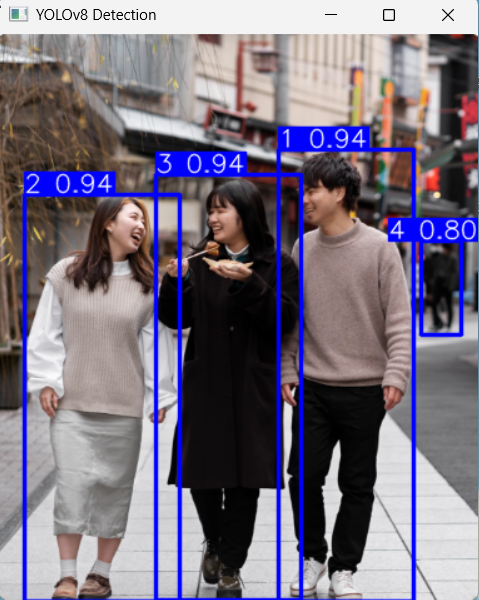 
 （a）原图
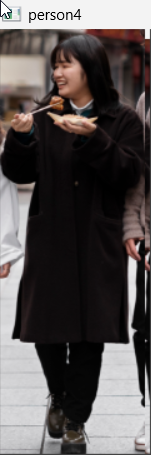  

（b） person 2（置信度0.94）</b>

### 体会与收获

本次作业让我熟悉了 YOLOv8 的基本使用流程，包括模型加载、目标检测、类别筛选、坐标读取与目标裁剪。

通过这次练习，我理解了“目标检测”不仅是把目标找出来，还要能够从检测结果中提取置信度、位置和尺寸等信息，并进一步做可视化展示。

和传统图像处理相比，YOLOv8 这种深度学习方法在检测人这种常见目标时更直接、更方便，也让我对后续学习计算机视觉有了更清晰的认识。

作为封装好的cv模型，YOLOv8让我体会到了不必再次“造轮子”的必要性，同时我也自行了解了YOLO一步输出目标框和类别的思想，以及pt权重文件。
#### 困难和解决
低置信度会使得图片上的招牌、树干、花盆认为成人。
解决：提高置信度，以及另一种我没有用到的方法——规则过滤——对xy进行限制，比例过于奇怪的不当人


